[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/himanshu231204/pytorch-mastery/blob/main/06_end_to_end_projects/llm_finetuning/llm_finetuning.ipynb)


# 03 . Tiny GPT: Pretraining then LoRA Finetuning (from scratch)

## Concept — Pretrain then finetune an LLM with LoRA (revision notes)

**What it is**
- A GPT is a stack of causal self-attention blocks trained to predict the next token.
  **Pretraining** teaches it the language; **instruction finetuning** teaches a *format*
  (`Q: ... A: ...`) and new behaviours using a few labelled examples.
- **LoRA** freezes the pretrained weights and learns a small low-rank update for selected
  linear layers, so only a few parameters are trained and stored.

**Why it matters**
- Full finetuning of a big model needs optimizer state for every weight; LoRA trains
  a small fraction and gives a tiny adapter file per task that can be swapped or merged.
- The loss mask (train only on answer tokens) and the zero-initialised adapter are the two
  details people most often get wrong.

**When to use**
- You have one base model and many small tasks/customers (one adapter each).
- GPU memory is limited. Not ideal when the new task needs a big shift in knowledge: the update is low rank.

**Math & intuition**
- Linear layer `y = W x`. LoRA: `y = W x + (alpha/r) * B A x` with `A: r x d_in`, `B: d_out x r`, `r` small.
  `B` starts at 0 so step 0 equals the base model exactly; `A` is random.
- Trainable params per layer: `r (d_in + d_out)` instead of `d_in * d_out`. After training you can
  merge: `W' = W + (alpha/r) B A`, giving zero extra inference cost.
- Next-token loss: `-log p(x_t | x_<t)`; for SFT we average only over answer positions.
- Honest note: with `d=64` the layers are so small that rank 8 is not a tiny fraction; at real model sizes
  (`d` in the thousands) the same rank is well under 1% of the weights.

### 1. Setup and imports

**What this cell does (plain language):** makes the folder importable, imports our `data`, `model` and `train` modules and seeds the RNG. Everything is char-level and tiny so the whole notebook runs on CPU in about a minute.

In [1]:
import os, sys, subprocess
# The notebook imports a small tested module that lives next to it.
# On Colab that folder is not there yet, so fetch the repo once and move into the project directory.
PROJECT = "06_end_to_end_projects/llm_finetuning"
if not os.path.exists("data.py"):
    if not os.path.exists("PyTorch-Mastery"):
        subprocess.run(["git", "clone", "-q", "https://github.com/himanshu231204/PyTorch-Mastery"], check=False)
    if os.path.isdir("PyTorch-Mastery/" + PROJECT):
        os.chdir("PyTorch-Mastery/" + PROJECT)
sys.path.insert(0, os.getcwd())

import copy, torch, torch.nn as nn, torch.nn.functional as F
import matplotlib.pyplot as plt
from data import (CharTokenizer, make_pretrain_text, make_instruction_pairs, sft_batch, lm_batch)
from model import TinyGPT, LoRALinear, apply_lora, merge_lora, count_params
from train import pretrain, finetune, complete, exact_match

torch.manual_seed(0)
print("torch", torch.__version__)

torch 2.14.1+cu130


### 2. Toy pretraining corpus and character tokenizer

**What this cell does (plain language):** builds ~33k characters of simple sentences (`the cat is hot .`) and a character tokenizer with 58 ids (57 characters plus padding). Characters keep the vocabulary tiny, so there is no BPE training to do; the cost is longer sequences.

In [2]:
text = make_pretrain_text(1500, seed=0)
tok = CharTokenizer()
ids = torch.tensor(tok.encode(text))
print(text[:150].replace("\n", "\\n "))
print("characters:", len(ids), "| vocab size:", len(tok))
print("encode/decode round trip ok:", tok.decode(tok.encode("the cat is hot .")) == "the cat is hot .")

the rain was very cold .\n i saw the low bread .\n the boat was very low .\n i saw the fast door .\n a up boat sat here .\n the wall is happy .\n a small boat sat
characters: 32757 | vocab size: 58
encode/decode round trip ok: True


### 3. Build the GPT and check the starting loss

**What this cell does (plain language):** creates a 3-layer, 4-head GPT with 64-dim embeddings and context 48. A freshly initialised language model knows nothing, so its loss should be about `ln(vocab)` (uniform guessing). If it is much higher, initialisation is wrong - we use small GPT-style init for exactly this reason.

In [3]:
torch.manual_seed(0)
model = TinyGPT(len(tok), d=64, heads=4, layers=3, block=48)
gen = torch.Generator().manual_seed(0)
x, y = lm_batch(ids, 48, 32, gen)
loss0 = F.cross_entropy(model(x).flatten(0, 1), y.flatten()).item()
print(f"parameters: {count_params(model)[0]:,}")
print(f"initial loss {loss0:.3f} vs ln(vocab) = {torch.log(torch.tensor(float(len(tok)))).item():.3f}")

parameters: 156,864
initial loss 4.077 vs ln(vocab) = 4.060


### 4. Verify causality (no peeking at the future)

**What this cell does (plain language):** changes the LAST token of a sequence and checks that the predictions for all EARLIER positions are unchanged. If a language model can see future tokens during training it just copies the answer and learns nothing.

In [4]:
model.eval()
a = torch.randint(1, len(tok), (1, 12)); b = a.clone(); b[0, -1] = (b[0, -1] % (len(tok) - 1)) + 1
print("earlier positions unaffected by the future token:", torch.allclose(model(a)[:, :-1], model(b)[:, :-1], atol=1e-5))
print("last position does change:", not torch.allclose(model(a)[:, -1], model(b)[:, -1], atol=1e-5))

earlier positions unaffected by the future token: True
last position does change: True


### 5. Pretrain on the toy corpus

**What this cell does (plain language):** trains for 400 steps of AdamW on random 48-character windows. The loss should fall from about 4 toward the entropy of the sentence templates (it never reaches zero because the next word is random).

pretrain step    0 | loss 4.077


pretrain step  100 | loss 1.120


pretrain step  200 | loss 0.575


pretrain step  300 | loss 0.456


pretrain step  399 | loss 0.448


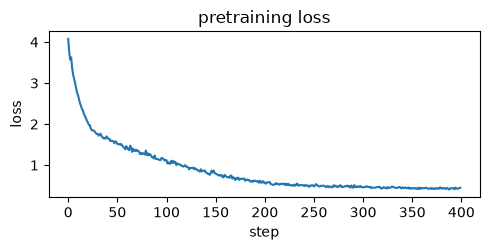

In [5]:
torch.manual_seed(0)
pre_losses = pretrain(model, ids, steps=400, bs=32, lr=3e-3, seed=0, log=100)
plt.figure(figsize=(5, 2.6)); plt.plot(pre_losses); plt.xlabel("step"); plt.ylabel("loss"); plt.title("pretraining loss"); plt.tight_layout(); plt.show()

### 6. Sample from the pretrained model

**What this cell does (plain language):** generates text from a short prompt with greedy decoding and with temperature sampling. Greedy always picks the most likely character (repetitive but stable); temperature > 0 samples (more varied). The base model writes plausible sentences but has never seen the `Q:`/`A:` format.

In [6]:
g = torch.Generator().manual_seed(1)
prompt = torch.tensor([tok.encode("the ")])
for temp in (0.0, 0.8):
    out = model.generate(prompt, max_new=60, temperature=temp, gen=g)
    print(f"temperature {temp}:", repr(tok.decode(out[0].tolist())))
print("\ninstruction prompt, base model:", repr(complete(model, tok, "Q: opposite hot\nA: ")))

temperature 0.0: 'the lamp was very hard .\nthe boat was very hard .\nthe boat is ha'


temperature 0.8: 'the big wolf .\nthe moon d was very old .\nthe bread was very new '

instruction prompt, base model: 's star .\n'


### 7. Instruction pairs and the loss mask

**What this cell does (plain language):** builds 40 (prompt, answer) pairs for two skills: `opposite X` and `kind X`. `sft_batch` encodes prompt+answer but marks ONLY answer characters in the loss mask. We print which target characters are trained on: if prompt tokens were included, the model would waste capacity (and be rewarded) for predicting the question.

In [7]:
train_pairs, eval_pairs = make_instruction_pairs(seed=0)
print(len(train_pairs), "pairs, e.g.", train_pairs[:2])
x, y, m = sft_batch(tok, train_pairs[:1], block=48)
print("full text     :", repr(train_pairs[0][0] + train_pairs[0][1]))
print("trained-on targets:", repr("".join(tok.itos[t] for t, k in zip(y[0].tolist(), m[0].tolist()) if k)))
print("base model exact-match on these pairs before finetuning:", exact_match(model, tok, eval_pairs))

40 pairs, e.g. [('Q: opposite hot\nA: ', 'cold\n'), ('Q: kind bell\nA: ', 'thing\n')]
full text     : 'Q: opposite hot\nA: cold\n'
trained-on targets: 'cold\n'


base model exact-match on these pairs before finetuning: 0.0


### 8. LoRA from scratch: wrap, freeze, and check B = 0

**What this cell does (plain language):** wraps every attention and MLP linear layer with a low-rank adapter (rank 8, alpha 16), freezes the base weights and prints how many parameters will train. Because `B` is zero-initialised, the wrapped model must produce exactly the same outputs as before - we assert this.

In [8]:
base_state = copy.deepcopy(model.state_dict())      # keep the pretrained weights for later comparisons
x_chk = torch.randint(1, len(tok), (2, 20))
model.eval(); before = model(x_chk)
apply_lora(model, r=8, alpha=16)
print("outputs unchanged right after wrapping:", torch.allclose(model(x_chk), before, atol=1e-6))
total, trainable = count_params(model)
print(f"total params {total:,} | trainable (LoRA only) {trainable:,} = {100 * trainable / total:.1f}%")
print("example adapter shapes:", model.blocks[0].attn.qkv.A.shape, model.blocks[0].attn.qkv.B.shape)
print("embedding frozen:", not model.tok.weight.requires_grad)

outputs unchanged right after wrapping: True
total params 181,440 | trainable (LoRA only) 24,576 = 13.5%
example adapter shapes: torch.Size([8, 64]) torch.Size([192, 8])
embedding frozen: True


### 9. Finetune only the adapters

**What this cell does (plain language):** trains for 300 steps on the instruction pairs, with the loss restricted to answer characters. Only `A` and `B` receive gradient updates; we confirm afterwards that the frozen base weights did not move.

finetune step    0 | answer loss 7.250


finetune step  100 | answer loss 0.070


finetune step  200 | answer loss 0.005


finetune step  299 | answer loss 0.003
base weight unchanged: True
adapter B moved away from zero: True


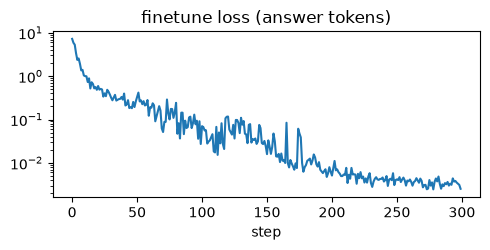

In [9]:
torch.manual_seed(0)
w_before = model.blocks[0].attn.qkv.base.weight.clone()
ft_losses = finetune(model, tok, train_pairs, steps=300, bs=16, lr=5e-3, seed=0, log=100)
print("base weight unchanged:", torch.equal(w_before, model.blocks[0].attn.qkv.base.weight))
print("adapter B moved away from zero:", model.blocks[0].attn.qkv.B.abs().max().item() > 0)
plt.figure(figsize=(5, 2.6)); plt.plot(ft_losses); plt.yscale("log"); plt.xlabel("step"); plt.title("finetune loss (answer tokens)"); plt.tight_layout(); plt.show()

### 10. Generate samples and measure exact match

**What this cell does (plain language):** prompts the finetuned model with every instruction and compares the generated answer to the target exactly. Exact-match accuracy is crude but honest for short answers. Note this tests *recall of taught facts*; arbitrary facts cannot be generalised to unseen ones.

In [10]:
acc = exact_match(model, tok, eval_pairs)
print(f"exact match after LoRA finetuning: {acc:.3f}")
for p, a in eval_pairs[:6]:
    print(f"{p!r:28s} -> {complete(model, tok, p)!r:10s} (target {a.strip()!r})")

exact match after LoRA finetuning: 1.000
'Q: opposite hot\nA: '       -> 'cold\n'   (target 'cold')
'Q: kind bell\nA: '          -> 'thing\n'  (target 'thing')
'Q: opposite old\nA: '       -> 'new\n'    (target 'new')
'Q: kind dog\nA: '           -> 'animal\n' (target 'animal')
'Q: kind boat\nA: '          -> 'thing\n'  (target 'thing')
'Q: opposite low\nA: '       -> 'high\n'   (target 'high')


### 11. Did finetuning damage the language model? Compare against the base

**What this cell does (plain language):** evaluates next-token loss on pretraining text with (a) the original base weights and (b) base + adapters. Expect a LARGE rise in the second number: the adapters were trained only on `Q:/A:` text, and they act on every input, so the model has largely forgotten how to continue plain sentences (catastrophic forgetting). The base weights themselves are untouched, so the first number shows the original model is fully recoverable by dropping the adapter - that is LoRA's safety net. To keep general ability you would mix pretraining text into the finetuning batches.

In [11]:
def lm_loss(m, n=20):
    g = torch.Generator().manual_seed(123); m.eval(); tot = 0
    with torch.no_grad():
        for _ in range(n):
            x, y = lm_batch(ids, 48, 32, g); tot += F.cross_entropy(m(x).flatten(0, 1), y.flatten()).item()
    return tot / n

fresh = TinyGPT(len(tok)); fresh.load_state_dict(base_state)
print(f"LM loss, base only        : {lm_loss(fresh):.3f}")
print(f"LM loss, base + adapters  : {lm_loss(model):.3f}")

LM loss, base only        : 0.427


LM loss, base + adapters  : 3.518


### 12. Merge the adapter and save only the adapter

**What this cell does (plain language):** folds `B A` into the base weights (`merge_lora`) and checks the generations are identical, so serving needs no extra layers. We also show that the adapter alone is much smaller than the full model; at real LLM scale this ratio is dramatic.

In [12]:
adapter = {k: v for k, v in model.state_dict().items() if k.endswith(".A") or k.endswith(".B")}
n_adapter = sum(v.numel() for v in adapter.values()); n_full = sum(p.numel() for p in fresh.parameters())
print(f"adapter tensors: {len(adapter)} | adapter params {n_adapter:,} vs full model {n_full:,}")

before_gen = [complete(model, tok, p) for p, _ in eval_pairs[:10]]
merge_lora(model)
after_gen = [complete(model, tok, p) for p, _ in eval_pairs[:10]]
print("any LoRALinear left after merge:", any(isinstance(m, LoRALinear) for m in model.modules()))
print("generations identical after merge:", before_gen == after_gen)

adapter tensors: 24 | adapter params 24,576 vs full model 156,864


any LoRALinear left after merge: False
generations identical after merge: True


## Common bugs

- **Computing the loss on prompt tokens too** — fix: you train the model to predict the question; mask to answer positions only (as `sft_batch` does).
- **Initialising both LoRA matrices randomly** — fix: the model changes before any training; keep `B = 0` so step 0 equals the base model.
- **Forgetting to freeze the base weights** — fix: you silently do full finetuning and lose the memory/storage benefit; set `requires_grad_(False)` and pass only trainable params to the optimiser.
- **Large embedding init with tied weights** — fix: initial loss far above `ln(vocab)` (we saw about 45 before fixing); use std 0.02 init.
- **No causal mask** — fix: loss collapses to ~0 because the model copies the next token; test that changing a future token never changes earlier outputs.
- **Not calling `model.eval()` / using `no_grad` when generating** — fix: dropout and autograd overhead; the `generate` method switches to eval and restores mode.
- **Generation never stops** — fix: stop on a newline/EOS token (`stop_id`) and always cap `max_new`.
- **Ignoring catastrophic forgetting** — fix: adapters change behaviour on all inputs; measure general-text loss (section 11) and mix replay data from the pretraining distribution into finetuning if you need both.
- **Judging by training loss alone** — fix: a low loss does not mean correct generations; measure exact match on prompts, and check for forgetting on general text.
- **Context overflow in `generate`** — fix: feeding more than `block` tokens breaks the position embedding; crop to the last `block` tokens (done here).

## Exercises

**Exercise 1.** Sample 5 continuations of `the ` at temperature 1.5 and at 0.3. Which are more diverse and why?

In [13]:
# Your attempt for Exercise 1 here

**Solution 1**

In [14]:
# Solution 1
g = torch.Generator().manual_seed(0)
for t in (1.5, 0.3):
    outs = [tok.decode(fresh.generate(torch.tensor([tok.encode("the ")]), max_new=25, temperature=t, gen=g)[0].tolist()) for _ in range(3)]
    print(t, outs)   # high temperature flattens the softmax -> more diverse and more errors

1.5 ['the lamp roDr .\na con fast mo', 'the new boag .\ni saw ked f.\na', 'the tre moon .\ni saw tholk wa']
0.3 ['the lamp was very soft .\nthe ', 'the lamp was very hard .\nthe ', 'the lamp was very hard .\ni sa']


**Exercise 2.** Re-run the LoRA finetune with rank 1 on a fresh copy of the base model. Does exact-match drop?

In [15]:
# Your attempt for Exercise 2 here

**Solution 2**

In [16]:
# Solution 2
m1 = TinyGPT(len(tok)); m1.load_state_dict(base_state); apply_lora(m1, r=1, alpha=2)
finetune(m1, tok, train_pairs, steps=300, lr=5e-3, verbose=False)
print("rank-1 trainable:", count_params(m1)[1], "exact match:", exact_match(m1, tok, eval_pairs))

rank-1 trainable: 3072 exact match: 0.925


**Exercise 3.** Apply LoRA only to `qkv` (not MLP layers) and report the trainable parameter count.

In [17]:
# Your attempt for Exercise 3 here

**Solution 3**

In [18]:
# Solution 3
m2 = TinyGPT(len(tok)); m2.load_state_dict(base_state); apply_lora(m2, r=8, alpha=16, targets=("qkv",))
print(count_params(m2))

(163008, 6144)


**Exercise 4.** Write `generate_with_top_k(model, idx, k)` that samples only from the k most likely characters.

In [19]:
# Your attempt for Exercise 4 here

**Solution 4**

In [20]:
# Solution 4
@torch.no_grad()
def top_k_step(m, idx, k=5):
    logits = m(idx[:, -m.block:])[:, -1]
    v, i = logits.topk(k); p = v.softmax(-1)
    return i.gather(-1, torch.multinomial(p, 1))
print(tok.decode(top_k_step(fresh.eval(), torch.tensor([tok.encode("the ")])).tolist()[0]))

m


**Exercise 5.** Check the merge math by hand: for one adapted layer verify `W + scale * B @ A` equals what `merged()` returns. (Use a fresh wrapped model.)

In [21]:
# Your attempt for Exercise 5 here

**Solution 5**

In [22]:
# Solution 5
m3 = TinyGPT(len(tok)); apply_lora(m3, r=4, alpha=8)
l = m3.blocks[0].fc1; nn.init.normal_(l.B, std=0.1)
print(torch.allclose(l.merged().weight, l.base.weight + l.scale * l.B @ l.A, atol=1e-6))

True


**Exercise 6.** Add a third skill, `kind` for adjectives (e.g. `Q: kind hot` -> `adjective`), finetune from the base, and test it.

In [23]:
# Your attempt for Exercise 6 here

**Solution 6**

In [24]:
# Solution 6
extra = [(f"Q: kind {a}\nA: ", "adjective\n") for a in ["hot", "cold", "big", "small", "fast", "slow"]]
m4 = TinyGPT(len(tok)); m4.load_state_dict(base_state); apply_lora(m4, r=8, alpha=16)
finetune(m4, tok, train_pairs + extra, steps=300, lr=5e-3, verbose=False)
print(exact_match(m4, tok, extra))

1.0
